# Pagina Streamlit - Neflix

#### Integrantes :
**José Manuel Colín Aguilar**  
**Ana Nicole Martinez Morales**  
**Diego Liberato Jury**

In [6]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 95.7 MB/s eta 0:00:00


## Importaciones

In [7]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Cargar DataSet


In [8]:
URL_DATASET = (
    "https://raw.githubusercontent.com/"
    "JoseColins1OO/Proyecto_Netflix/"
    "refs/heads/main/data/processed/netflix_clean.csv"
)

df = pd.read_csv(URL_DATASET)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Filas: 7689
Columnas: 23


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,month_added,duration_num,duration_unit,director_count,cast_count,country_count,main_genre,content_age,is_multicountry,is_long_content
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,...,8,4.0,Seasons,1,11,1,International TV Shows,6,0,0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,...,12,93.0,min,1,6,1,Dramas,10,0,0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,...,12,78.0,min,1,9,1,Horror Movies,15,0,0
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,...,11,80.0,min,1,9,1,Action & Adventure,17,0,0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,...,1,123.0,min,1,12,1,Dramas,18,0,1


## Procesamiento de datos


In [9]:
df["duration_unit"] = (
    df["duration_unit"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [10]:
def normalizar_duracion(row):

    if pd.isna(row["duration_num"]):
        return np.nan

    if row["duration_unit"] in [
        "min",
        "mins",
        "minute",
        "minutes"
    ]:
        return row["duration_num"]

    if row["duration_unit"] in [
        "season",
        "seasons"
    ]:
        return row["duration_num"] * 30

    return row["duration_num"]


df["duration_model"] = df.apply(
    normalizar_duracion,
    axis=1
)

In [11]:
df[
    [
        "type",
        "duration_num",
        "duration_unit",
        "duration_model"
    ]
].head(20)

,type,duration_num,duration_unit,duration_model
0,TV Show,4.0,seasons,120.0
1,Movie,93.0,min,93.0
2,Movie,78.0,min,78.0
3,Movie,80.0,min,80.0
4,Movie,123.0,min,123.0
5,TV Show,1.0,season,30.0
6,Movie,95.0,min,95.0
7,Movie,119.0,min,119.0
8,Movie,118.0,min,118.0
9,Movie,143.0,min,143.0


In [12]:
features = [
    "release_year",
    "year_added",
    "month_added",
    "duration_model",
    "director_count",
    "cast_count",
    "country_count",
    "content_age",
    "is_multicountry",
    "is_long_content",
    "main_genre",
    "rating"
]

target = "type"

## One hot encoding

In [13]:
model_df = df[features + [target]].copy()

encoders = {}

categorical_columns = [
    "main_genre",
    "rating",
    "type"
]

for column in categorical_columns:

    encoder = LabelEncoder()

    model_df[column] = encoder.fit_transform(
        model_df[column].astype(str)
    )

    encoders[column] = encoder

## Variables


In [14]:
numeric_columns = [
    "release_year",
    "year_added",
    "month_added",
    "duration_model",
    "director_count",
    "cast_count",
    "country_count",
    "content_age",
    "is_multicountry",
    "is_long_content"
]

for column in numeric_columns:

    model_df[column] = model_df[column].fillna(
        model_df[column].median()
    )

## Separacion test y train

In [15]:
X = model_df.drop(columns=["type"])
y = model_df["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Modelo

In [16]:
modelo = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

## Evaluacion

In [17]:
y_pred = modelo.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy, 4))

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoders["type"].classes_
    )
)

Accuracy: 0.9837

Reporte de clasificación:
              precision    recall  f1-score   support

       Movie       0.98      0.99      0.99      1076
     TV Show       0.98      0.96      0.97       462

    accuracy                           0.98      1538
   macro avg       0.98      0.98      0.98      1538
weighted avg       0.98      0.98      0.98      1538



In [18]:
importancias = pd.DataFrame({
    "Caracteristica": X.columns,
    "Importancia": modelo.feature_importances_
})

importancias = importancias.sort_values(
    "Importancia",
    ascending=False
)

importancias

,Caracteristica,Importancia
3,duration_model,0.921637
10,main_genre,0.055721
11,rating,0.017315
5,cast_count,0.005022
7,content_age,0.000273
4,director_count,0.000031
0,release_year,0.000000
1,year_added,0.000000
2,month_added,0.000000
6,country_count,0.000000


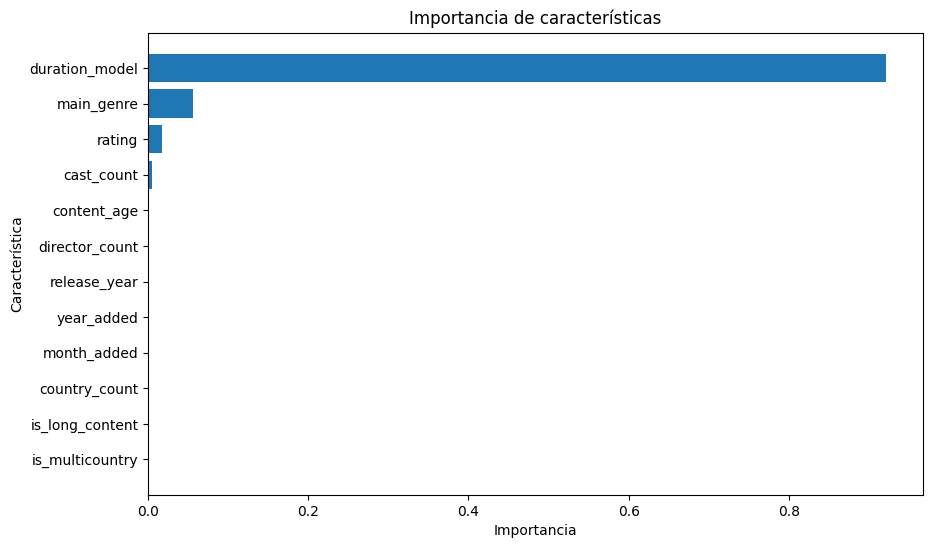

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importancias["Caracteristica"],
    importancias["Importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.title("Importancia de características")

plt.gca().invert_yaxis()

plt.show()

## Codigo Streamlit

In [27]:

%%writefile Netflix_Streamlit.py

import pandas as pd
import streamlit as st

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split


# ============================================================
# CONFIGURACIÓN
# ============================================================

st.set_page_config(
    page_title="Netflix Content Classifier",
    page_icon="🎬",
    layout="wide"
)


# ============================================================
# CARGAR DATOS
# ============================================================

URL_DATASET = (
    "https://raw.githubusercontent.com/"
    "JoseColins1OO/Proyecto_Netflix/"
    "refs/heads/main/data/processed/netflix_clean.csv"
)


@st.cache_data
def cargar_datos():

    df = pd.read_csv(URL_DATASET)

    df["duration_unit"] = (
        df["duration_unit"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    def normalizar_duracion(row):

        if pd.isna(row["duration_num"]):
            return None

        if row["duration_unit"] in [
            "min",
            "mins",
            "minute",
            "minutes"
        ]:
            return row["duration_num"]

        if row["duration_unit"] in [
            "season",
            "seasons"
        ]:
            return row["duration_num"] * 30

        return row["duration_num"]

    df["duration_model"] = df.apply(
        normalizar_duracion,
        axis=1
    )

    return df


df = cargar_datos()


# ============================================================
# ENTRENAMIENTO
# ============================================================

@st.cache_resource
def entrenar(df):

    features = [
        "release_year",
        "year_added",
        "month_added",
        "duration_model",
        "director_count",
        "cast_count",
        "country_count",
        "content_age",
        "is_multicountry",
        "is_long_content",
        "main_genre",
        "rating"
    ]

    model_df = df[
        features + ["type"]
    ].copy()

    encoders = {}

    for column in [
        "main_genre",
        "rating",
        "type"
    ]:

        encoder = LabelEncoder()

        model_df[column] = encoder.fit_transform(
            model_df[column].astype(str)
        )

        encoders[column] = encoder

    numeric_columns = [
        "release_year",
        "year_added",
        "month_added",
        "duration_model",
        "director_count",
        "cast_count",
        "country_count",
        "content_age",
        "is_multicountry",
        "is_long_content"
    ]

    for column in numeric_columns:

        model_df[column] = model_df[column].fillna(
            model_df[column].median()
        )

    X = model_df.drop(
        columns=["type"]
    )

    y = model_df["type"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    modelo = DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        random_state=42
    )

    modelo.fit(
        X_train,
        y_train
    )

    return modelo, encoders


modelo, encoders = entrenar(df)


# ============================================================
# ENCABEZADO
# ============================================================

st.title("🎬 Netflix Content Classifier")

st.markdown("""
### 👥 Integrantes del equipo

**José Manuel Colín Aguilar**
**Ana Nicole Martinez Morales**
**Diego Liberato Jury**
""")


# ============================================================
# CONTEXTO DEL PROYECTO
# ============================================================

st.divider()

st.markdown("""
## Contexto del proyecto

Netflix cuenta con un amplio catálogo de contenidos que incluye
**películas y series** con diferentes características de producción,
clasificación, género, duración y distribución.

En este proyecto se desarrolló un modelo de **Machine Learning**
utilizando un **árbol de decisión**, cuyo objetivo es analizar las
características de un contenido y determinar automáticamente si
corresponde a una **película** o una **serie**.

### ¿Cómo funciona?

El usuario proporciona algunas características del contenido,
como:

- 🎞️ Año de lanzamiento
- 📅 Año de incorporación a Netflix
- ⏱️ Duración aproximada
- 🎭 Género
- 🔞 Clasificación
- 🎬 Número de directores y actores
- 🌎 Número de países involucrados
- 📊 Otras características del contenido

A partir de estos datos, el modelo analiza los patrones aprendidos
del catálogo de Netflix y genera una **predicción**, acompañada de
la probabilidad estimada para cada tipo de contenido.

> **El reto:** proporciona las características del contenido,
> pero no indiques si es una película o una serie.
> **¡Deja que el modelo lo descubra!**
""")


# ============================================================
# SEPARADOR
# ============================================================

st.divider()

st.markdown("""
## 🔮 Realiza una predicción

Ingresa las características del contenido y presiona
**"Clasificar contenido"** para conocer el resultado.
""")

# ============================================================
# ENTRADA
# ============================================================

col1, col2 = st.columns(2)


with col1:

    release_year = st.number_input(
        "Año de lanzamiento",
        1920,
        2026,
        2020
    )

    year_added = st.number_input(
        "Año de incorporación",
        2008,
        2026,
        2021
    )

    month_added = st.slider(
        "Mes de incorporación",
        1,
        12,
        6
    )

    duration = st.slider(
        "Duración aproximada",
        1,
        300,
        120
    )


with col2:

    director_count = st.number_input(
        "Número de directores",
        0,
        20,
        1
    )

    cast_count = st.number_input(
        "Número de actores",
        0,
        50,
        10
    )

    country_count = st.number_input(
        "Número de países",
        1,
        20,
        1
    )

    content_age = st.number_input(
        "Antigüedad del contenido",
        0,
        30,
        1
    )


# ============================================================
# PRODUCCIÓN
# ============================================================

multicountry = st.selectbox(
    "¿Participan varios países?",
    ["No", "Sí"]
)

is_multicountry = (
    1 if multicountry == "Sí"
    else 0
)

long_content = st.selectbox(
    "¿Contenido largo?",
    ["No", "Sí"]
)

is_long_content = (
    1 if long_content == "Sí"
    else 0
)


# ============================================================
# CATEGORÍAS
# ============================================================

genre = st.selectbox(
    "Género",
    sorted(
        df["main_genre"]
        .dropna()
        .astype(str)
        .unique()
    )
)

rating = st.selectbox(
    "Clasificación",
    sorted(
        df["rating"]
        .dropna()
        .astype(str)
        .unique()
    )
)


# ============================================================
# PREDICCIÓN
# ============================================================

if st.button(
    "Clasificar contenido",
    use_container_width=True
):

    genre_encoded = encoders[
        "main_genre"
    ].transform([genre])[0]

    rating_encoded = encoders[
        "rating"
    ].transform([rating])[0]

    entrada = pd.DataFrame([
        {
            "release_year": release_year,
            "year_added": year_added,
            "month_added": month_added,
            "duration_model": duration,
            "director_count": director_count,
            "cast_count": cast_count,
            "country_count": country_count,
            "content_age": content_age,
            "is_multicountry": is_multicountry,
            "is_long_content": is_long_content,
            "main_genre": genre_encoded,
            "rating": rating_encoded
        }
    ])

    prediccion = modelo.predict(entrada)

    resultado = encoders[
        "type"
    ].inverse_transform(
        prediccion
    )[0]

    probabilidades = modelo.predict_proba(
        entrada
    )[0]

    clases = encoders[
        "type"
    ].classes_


    # ========================================================
    # RESULTADO
    # ========================================================

    st.subheader("🔮 Resultado")

    if resultado == "Movie":

        st.success(
            "🎬 El modelo predice: **PELÍCULA**"
        )

        st.image(
            "https://images.unsplash.com/photo-1489599849927-2ee91cede3ba"
            "?auto=format&fit=crop&w=1200&q=80",
            caption="🎬 Película",
            use_container_width=True
        )

    else:

        st.info(
            "📺 El modelo predice: **SERIE**"
        )

        st.image(
            "https://images.unsplash.com/photo-1593784991095-a205069470b6"
            "?auto=format&fit=crop&w=1200&q=80",
            caption="📺 Serie",
            use_container_width=True
        )


    # ========================================================
    # PROBABILIDADES
    # ========================================================

    st.subheader("📊 Probabilidades")

    resultados = pd.DataFrame({
        "Tipo": clases,
        "Probabilidad": probabilidades * 100
    })

    resultados["Probabilidad"] = (
        resultados["Probabilidad"]
        .round(2)
    )

    st.bar_chart(
        resultados.set_index("Tipo")
    )


    # ========================================================
    # CONFIANZA
    # ========================================================

    confianza = max(probabilidades) * 100

    st.metric(
        "Confianza",
        f"{confianza:.2f}%"
    )


    # ========================================================
    # DATOS
    # ========================================================

    with st.expander(
        "🔎 Ver datos utilizados"
    ):

        st.dataframe(
            entrada
        )



Writing Netflix_Streamlit.py


## Link streamlit: `https://netflix-jmca-anmm-dlj.streamlit.app/`